## Long term memory
- Long term memory is useful for storing information across sessions, such as user preferences, past interactions, and other data that can enhance the user experience over time. It allows the system to remember important details about the user and their interactions, which can be used to provide more personalized and relevant responses in future conversations.

In [41]:
from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage, AIMessage
from typing import TypedDict, Sequence, Annotated, List
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnableConfig
from pydantic import BaseModel, Field
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END, add_messages, MessagesState
from langgraph.store.memory import InMemoryStore, BaseStore
from langgraph.checkpoint.memory import InMemorySaver
import uuid

load_dotenv()

True

### Basics of store

In [3]:
store = InMemoryStore()

In [5]:
namespace = ("users", "mainak", "details")

- Stroing data in store

In [6]:
store.put(namespace, "name", {"value": "Mainak Mukherjee"})
store.put(namespace, "age", {"value": 23})
store.put(namespace, "hobbies", {"value": ["coding", "playing", "travelling"]})

- Retrieving data from store by `key`

In [8]:
store.get(namespace, "age").value

{'value': 23}

- Retrieving all data from store by

In [10]:
items = store.search(namespace)

for item in items:
    print(f"key: {item.key} value: {item.value}")

key: name value: {'value': 'Mainak Mukherjee'}
key: age value: {'value': 23}
key: hobbies value: {'value': ['coding', 'playing', 'travelling']}


#### Store with `semantic search` capabilities

In [13]:
embed_model = GoogleGenerativeAIEmbeddings(model = 'gemini-embedding-2')

In [15]:
namespace = ("users", "mainak", "preferences")

In [14]:
store = InMemoryStore(
    index = {
        'dims': 768,
        'embed': embed_model,
        'fields': ['text', 'value']
    }
)

In [ ]:
store.put(namespace, "k1", {'text': "User likes dark mode"})
store.put(namespace, "k2", {'text': "User prefers email notifications"})
store.put(namespace, "k3", {'text': "User likes cutting-edge technology"})
store.put(namespace, "k4", {'text': 'User works in Cognizant as a Jr. Software Engineer'})
store.put(namespace, "k5", {'text': 'User is learning about GenAI'})
store.put(namespace, "k6", {'text': 'The name of the user is Mainak Mukherjee'})

In [23]:
res = store.search(namespace, query = 'Which theme does the user prefer in websites?', limit = 2)

for item in res:
    print(f"key: `{item.key}`, text: `{item.value}`, confidence_score: `{round(item.score, 2)}`")

key: `k1`, text: `{'text': 'User likes dark mode'}`, confidence_score: `0.82`
key: `k2`, text: `{'text': 'User prefers email notifications'}`, confidence_score: `0.69`


### Store with LLM

In [8]:
store = InMemoryStore()

memory_llm = ChatGoogleGenerativeAI(model='gemini-3.1-flash-lite-preview')
llm = ChatGoogleGenerativeAI(model='gemini-3.1-flash-lite-preview')

In [ ]:
class Memory(BaseModel):
    key: str = Field(
        description=(
            "Unique identifier for an existing memory item. "
            "Leave this as an empty string ('') if this is a new memory to be created. "
            "If updating an existing memory, this must exactly match the key of that memory."
        )
    )

    value: str = Field(
        description=(
            "A single, atomic, self-contained fact or preference extracted from the conversation. "
            "It must be concise, unambiguous, and independently meaningful without additional context. "
            "Do NOT combine multiple facts into one memory."
        )
    )

    is_new: bool = Field(
        description=(
            "Indicates whether this memory is new or an update. "
            "Set to true if this is a newly identified memory not present in existing memory. "
            "Set to false if this updates or refines an existing memory."
        )
    )


class MemoryOutput(BaseModel):
    memories: List[Memory] = Field(
        default_factory=list,
        description=(
            "A list of memory objects extracted from the conversation. "
            "Only include memories that are important for long-term personalization, "
            "such as user preferences, goals, habits, identity, or persistent facts. "
            "Return an empty list if no relevant memory is found."
        )
    )

In [9]:
memory_llm = memory_llm.with_structured_output(schema=MemoryOutput)

In [21]:
SYSTEM_PROMPT = '''
You are a high-precision memory extraction and reconciliation system.

Your task is to analyze the conversation and compare it against existing memories to determine:
1. What new memories should be added
2. What existing memories should be updated
3. What should be ignored

---

### INPUTS

1. User query: The latest query of the user
2. Existing Memories: A list of previously stored memory objects (`key`:`value` pairs), can be empty.

---

### CORE OBJECTIVE

Maintain a clean, minimal, and accurate long-term memory store by:
- Adding new meaningful memories
- Updating outdated or incomplete memories
- Avoiding duplicates and noise

---

### STEP 1: IDENTIFY CANDIDATE MEMORIES

From the conversation, extract only information that is:
- Persistent over time (not temporary)
- Specific to the user
- Useful for long-term personalization

Examples:
- Preferences
- Goals
- Skills
- Interests
- Stable habits or constraints

---

### STEP 2: COMPARE WITH EXISTING MEMORIES

For each candidate memory:

- If it is completely new:
  → Create a new memory (key = "", is_new = true)

- If it overlaps with an existing memory:
  → Decide if it:
     a) Adds new detail → UPDATE existing memory
     b) Contradicts old info → REPLACE existing memory
     c) Is already covered → IGNORE

- When updating:
  -> If the exact same information is already present in the memory, IGNORE, DO NOT ADD THIS IN THE OUTPUT.
  -> Else:
    → Reuse the exact existing key
    → Set is_new = false
    → Produce a refined, complete version of the memory

---

### STEP 3: ATOMICITY RULE (STRICT)

Each memory must contain exactly ONE fact.

DO NOT combine multiple facts.

---

### STEP 4: SELF-CONTAINED RULE

Each memory must be fully understandable on its own without needing conversation context.

---

### STEP 5: WHAT NOT TO STORE

Do NOT include:
- Temporary or short-term context
- One-time requests
- Generic or obvious statements
- Assistant-generated content

---

### STEP 6: CONSERVATIVE FILTER

Only include high-value memories.

If unsure → DO NOT INCLUDE.

---

### OUTPUT

Return a list of memory objects representing:
- New memories to add
- Existing memories to update

Return an empty list if no action is needed.
'''

memory_extractor_prompt = ChatPromptTemplate.from_messages(messages = [
    ('system', SYSTEM_PROMPT),
    ('user', 'Query: {query}\nExisting memory: {memory}')
])

memory_extractor_chain = memory_extractor_prompt | memory_llm 

In [ ]:
# memory_extractor_chain.invoke({
#     'query': 'Hi, my name is Mainak Chatterjee',
#     'memory': [{
#         'name-001': "The user's name is Mainak Mukherjee."
#     }]
# })

MemoryOutput(memories=[Memory(key='name-001', value="The user's name is Mainak Chatterjee.", is_new=False)])

In [46]:
def create_memory_node(state: MessagesState, config: RunnableConfig, store: BaseStore) -> MessagesState:
    namespace = ("users", config['configurable']['user_id'], "details")

    existing_memory = [{item.key: item.value} for item in store.search(namespace)]

    memories = memory_extractor_chain.invoke({
        'query': state['messages'][-1].content,
        'memory': existing_memory
    })

    for memory in memories.memories:
        if memory.is_new:
            store.put(namespace, uuid.uuid4(), memory.value)
            print(f'New memory created: {memory.value}')
        else:
            store.put(namespace, memory.key, memory.value)
            print(f'Memory updated: {memory.value}, key: {memory.key}')

    return state



In [28]:
config: RunnableConfig = {
    'configurable': {
        'user_id': 'mainak',
        'thread_id': 'mainak-thread-1'
    }
}

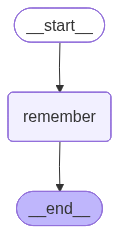

In [26]:
graph = StateGraph(MessagesState)

graph.add_node('remember', create_memory_node)

graph.add_edge(START, 'remember')
graph.add_edge('remember', END)

agent = graph.compile(store=store)
agent

In [29]:
agent.invoke({'messages': [HumanMessage(content = 'Hi, My name is Mainak Mukherjee')]}, config=config)
agent.invoke({'messages': [HumanMessage(content = 'Hi, I work in Cognizant as a Jr. Software Engineer')]}, config=config)
agent.invoke({'messages': [HumanMessage(content = 'I am waiting for Infosys to send me new DOJ, as I am serving notice period in Cognizant, I was not able to join on the previous DOJ that was given by infosys, and I opted for offer letter extension.')]}, config=config)
agent.invoke({'messages': [HumanMessage(content = 'What is langgraph?')]}, config=config)

{'messages': [HumanMessage(content='What is langgraph?', additional_kwargs={}, response_metadata={}, id='e1df7dc7-7556-4646-a543-bea8560ff4e0')]}

In [32]:
res = store.search(('users', 'mainak', 'details'))

for item in res:
    print(f"key: `{item.key}`, value: `{item.value}`")

key: `71ac207b-4dcd-4ab3-bd9b-20f79077b2db`, value: `The user's name is Mainak Mukherjee.`
key: `a86dfcb9-7550-4082-98a7-84c42d8cec5e`, value: `The user works at Cognizant as a Jr. Software Engineer.`
key: `fb4fdadf-1bfc-4605-a660-6ef06f69c4d7`, value: `The user is currently serving their notice period at Cognizant.`
key: `8bb69846-178d-4002-b74a-a44a32a0f28b`, value: `The user has an offer from Infosys and is awaiting a new Date of Joining (DOJ) after requesting an extension.`


#### Let's check if it can effectively update the stored information if needed

In [33]:
agent.invoke({'messages': [HumanMessage(content = 'Hi, My name is Sinchana Mukherjee')]}, config=config)

{'messages': [HumanMessage(content='Hi, My name is Sinchana Mukherjee', additional_kwargs={}, response_metadata={}, id='8a5afbbc-4105-41d5-bae9-b29a630533bb')]}

In [ ]:
res = store.search(('users', 'mainak', 'details'))

for item in res:
    print(f"key: `{item.key}`, value: `{item.value}`")  # Successfully updated.

key: `71ac207b-4dcd-4ab3-bd9b-20f79077b2db`, value: `The user's name is Sinchana Mukherjee.`
key: `a86dfcb9-7550-4082-98a7-84c42d8cec5e`, value: `The user works at Cognizant as a Jr. Software Engineer.`
key: `fb4fdadf-1bfc-4605-a660-6ef06f69c4d7`, value: `The user is currently serving their notice period at Cognizant.`
key: `8bb69846-178d-4002-b74a-a44a32a0f28b`, value: `The user has an offer from Infosys and is awaiting a new Date of Joining (DOJ) after requesting an extension.`


### Adding LLM node to the to answer user's question based on the stored information

- Also integrating short-term memory to answer user's question based on the stored information and the current conversation context

In [42]:
checkpointer = InMemorySaver()

In [37]:
ans_prompt_system = '''
You are a helpful and conversational assistant.

If the user’s name is present in memory, always greet them by their name naturally at the beginning of the response.

Use the user’s stored memories (preferences, goals, interests, etc.) along with the current query to personalize your response. Remember, it can be empty if no data about the user is present.

At the end of your reply, ask 2–3 relevant follow-up questions that:
- Are directly related to the user’s current query
- Leverage known user memories when appropriate
- Help deepen the conversation or clarify intent

Keep the tone natural and non-repetitive. Do not force the name if it feels unnatural, but use it whenever appropriate.
'''

prompt = ChatPromptTemplate.from_messages(
    messages = [
        ('system', ans_prompt_system),
        ('user',"Query: {query}, Details about the user: {memory}")
    ]
)

ans_chain = prompt | llm

In [39]:
def llm_node(state: MessagesState, config: RunnableConfig, store: BaseStore) -> MessagesState:
    namespace = ("users", config['configurable']['user_id'], "details")

    memory = [{item.key: item.value} for item in store.search(namespace)]

    answer = ans_chain.invoke({
        'query': state['messages'][-1].content,
        'memory': memory
    })

    return {'messages': [answer]}

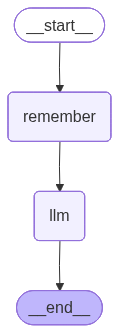

In [47]:
final_graph = StateGraph(MessagesState)

final_graph.add_node('remember', create_memory_node)
final_graph.add_node('llm', llm_node)

final_graph.add_edge(START, 'remember')
final_graph.add_edge('remember', 'llm')
final_graph.add_edge('llm', END)

final_agent = final_graph.compile(store=store, checkpointer=checkpointer)
final_agent

In [ ]:
final_agent.invoke({'messages': 'My name is Mainak Mukherjee'}, config=config)
res = final_agent.invoke({'messages': 'I love to learn cutting edge technolodgies, e.g, GenAI, Cloud, DevOps, etc.'}, config=config)

print(StrOutputParser().invoke(res['messages'][-1])) # The llm perfectly answers my question with both short-term and long-term memory context

Memory updated: The user's name is Mainak Mukherjee., key: 71ac207b-4dcd-4ab3-bd9b-20f79077b2db
Hi Mainak Mukherjee! It's great to see your drive for staying ahead of the curve, especially while you're in the middle of such a significant professional transition. Balancing your notice period at Cognizant while preparing for your new role at Infosys is the perfect time to sharpen those skills.

Since you're interested in GenAI, Cloud, and DevOps, there is a lot of synergy you can tap into right now. For example, you could explore **LLMOps**, which is essentially the intersection of DevOps and GenAI, focusing on the deployment, monitoring, and lifecycle management of large language models. It’s a very high-demand area that bridges your current interests perfectly.

Given your role as a Jr. Software Engineer and your upcoming move, focusing on how these technologies can automate CI/CD pipelines or improve developer productivity might give you a nice head start at Infosys.

To help you narr